In [1]:
"""Goal: Visualize how different classifiers carve up the feature space. You’ll:
Pick two features (2D),
Train a few classifiers,
Plot decision regions and the test points,
Compare boundaries and discuss bias/variance.
 pip install scikit-learn matplotlib seaborn
"""
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
#Choose dataset & two features
#We’ll use Iris and focus on petal length & petal width (good separation).
iris = datasets.load_iris()
feat_idx = [2, 3]                           # petal length, petal width
X = iris.data[:, feat_idx]
y = iris.target
names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [3]:
#Helper: plot decision regions
def plot_decision_regions(ax, model, X_train, y_train, X_test, y_test, title, h=0.02):
    # Fit
    model.fit(X_train, y_train)
    # Mesh
    x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
    y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Plot regions + points
    ax.contourf(xx, yy, Z, alpha=0.25)
    for i, lab in enumerate(names):
        pts_tr = X_train[y_train==i]
        pts_te = X_test[y_test==i]
        ax.scatter(pts_tr[:,0], pts_tr[:,1], label=f"{lab} (train)", alpha=0.7, s=25)
        ax.scatter(pts_te[:,0], pts_te[:,1], label=f"{lab} (test)",  alpha=1.0, s=35, marker='x')
    ax.set_title(title)
    ax.set_xlabel(iris.feature_names[feat_idx[0]])
    ax.set_ylabel(iris.feature_names[feat_idx[1]])
    # Keep legend compact
    handles, labels = ax.get_legend_handles_labels()
    # show only test labels once
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), fontsize=8, ncol=2, loc='upper left')

In [4]:
#Models to compare
#Scale features for distance‑based / margin‑based models.
models = [
    ("k-NN (k=5)", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))),
    ("Logistic Regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    ("SVM (RBF)", make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma='scale', C=1.0))),
    ("Decision Tree (depth=4)", DecisionTreeClassifier(max_depth=4, random_state=0)),
]


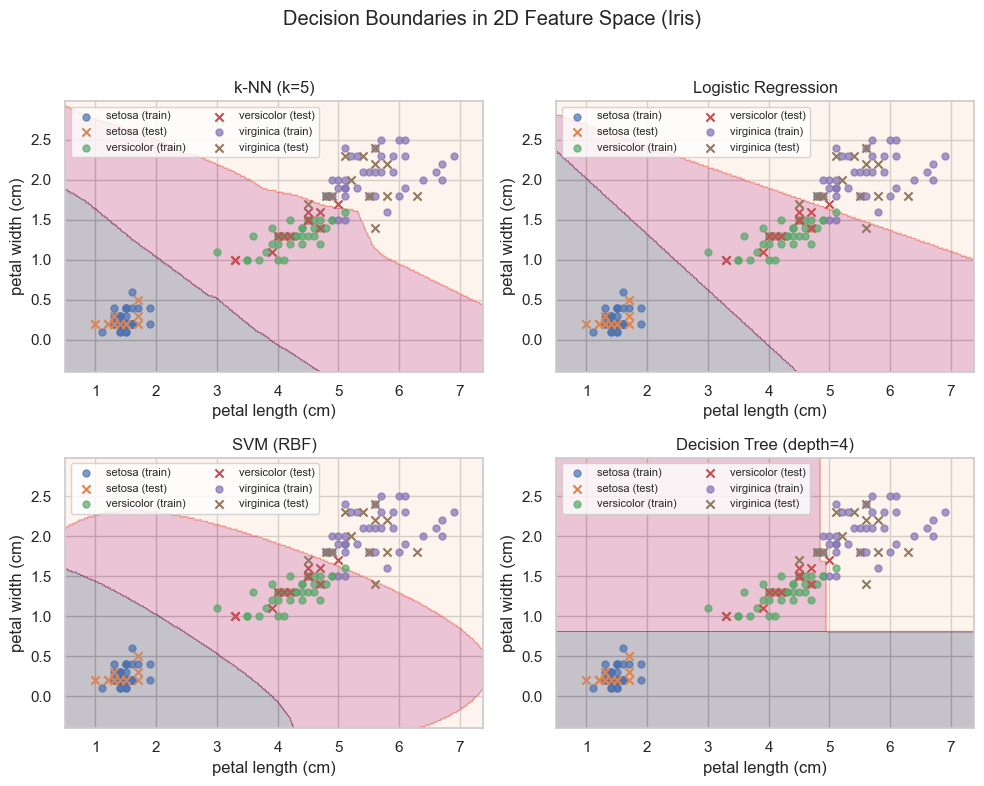

In [5]:
#Plot a 2×2 dashboard of boundaries
fig, axes = plt.subplots(2, 2, figsize=(10,8))
for ax, (name, model) in zip(axes.ravel(), models):
    plot_decision_regions(ax, model, X_train, y_train, X_test, y_test, title=name)
fig.suptitle("Decision Boundaries in 2D Feature Space (Iris)", y=0.98)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

## What to notice

- **Logistic Regression** draws (almost) linear boundaries.
- **SVM (RBF)** makes smooth, curved boundaries.
- **k-NN** is locally wiggly; higher k → smoother.
- **Trees** produce axis-aligned, blocky regions; shallower depth → coarser blocks.

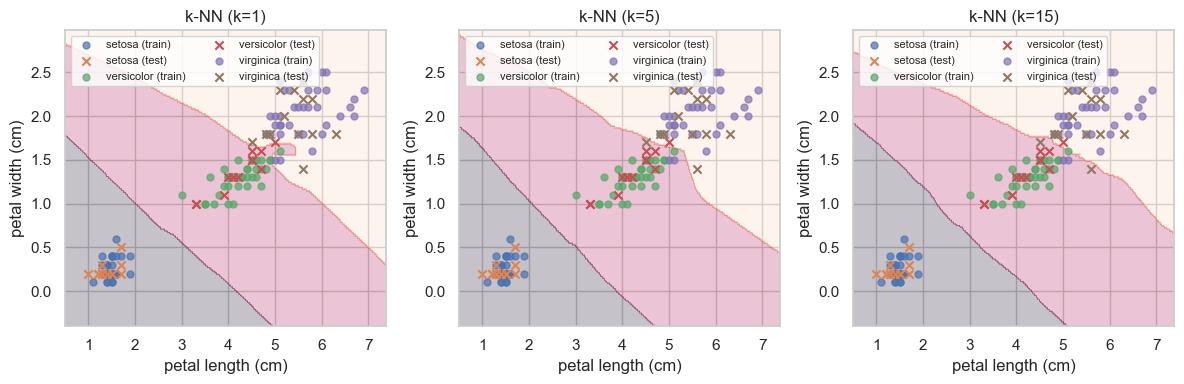

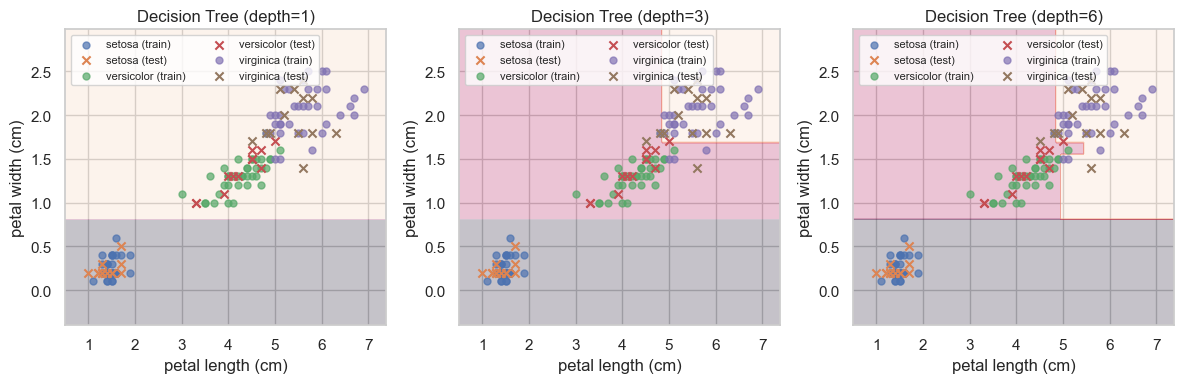

In [6]:
#Try different k and tree depth
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, k in zip(axes, [1, 5, 15]):
    mdl = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    plot_decision_regions(ax, mdl, X_train, y_train, X_test, y_test, title=f'k-NN (k={k})')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, d in zip(axes, [1, 3, 6]):
    mdl = DecisionTreeClassifier(max_depth=d, random_state=0)
    plot_decision_regions(ax, mdl, X_train, y_train, X_test, y_test, title=f'Decision Tree (depth={d})')
plt.tight_layout(); plt.show()

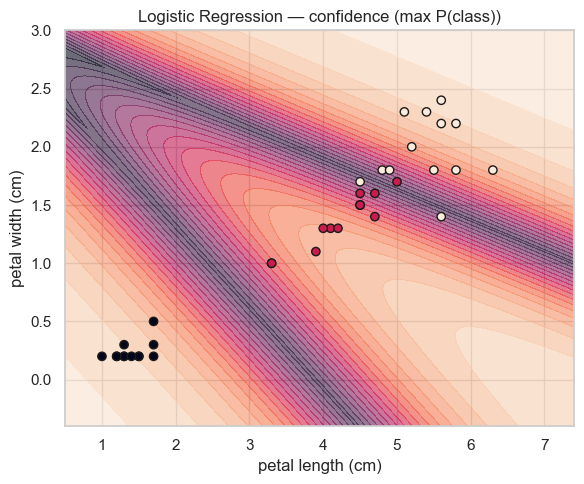

In [7]:
"""(Optional) Add class probability shading
For probabilistic models (Logistic), visualize confidence."""
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logit.fit(X_train, y_train)

x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
proba = logit.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape + (-1,))

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, proba.max(axis=2), levels=20, alpha=0.6)  # max class probability
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolor='k')
plt.title("Logistic Regression — confidence (max P(class))")
plt.xlabel(iris.feature_names[feat_idx[0]]); plt.ylabel(iris.feature_names[feat_idx[1]])
plt.tight_layout(); plt.show()

## Explanation: Logistic Regression Confidence Map

This graph visualizes the **confidence level** of the Logistic Regression classifier across the feature space:

- **Color intensity** represents the maximum predicted probability for any class at that location
  - Darker/more saturated colors = high confidence (close to 1.0)
  - Lighter colors = low confidence (close to 0.33, near class boundary)

- **Decision boundaries** appear as sharp transitions where the model switches from one class to another
  - Since Logistic Regression is linear, boundaries are (mostly) straight lines

- **Blue points** show test samples from the Iris dataset
  - Points in high-confidence regions are well within class territories
  - Points near boundaries may be misclassified

**Insight**: Logistic Regression assigns high confidence to regions far from decision boundaries and lower confidence near boundaries (where multiple classes have similar probabilities).

In [ ]:
## Experiment: Lower Separability
"""
Now switch to **sepal length & sepal width** (feat_idx = [0, 1]), which have **much lower class separability**.
This challenges the classifiers more—some will overfit, others will smooth robustly.
Compare which models cope best."""

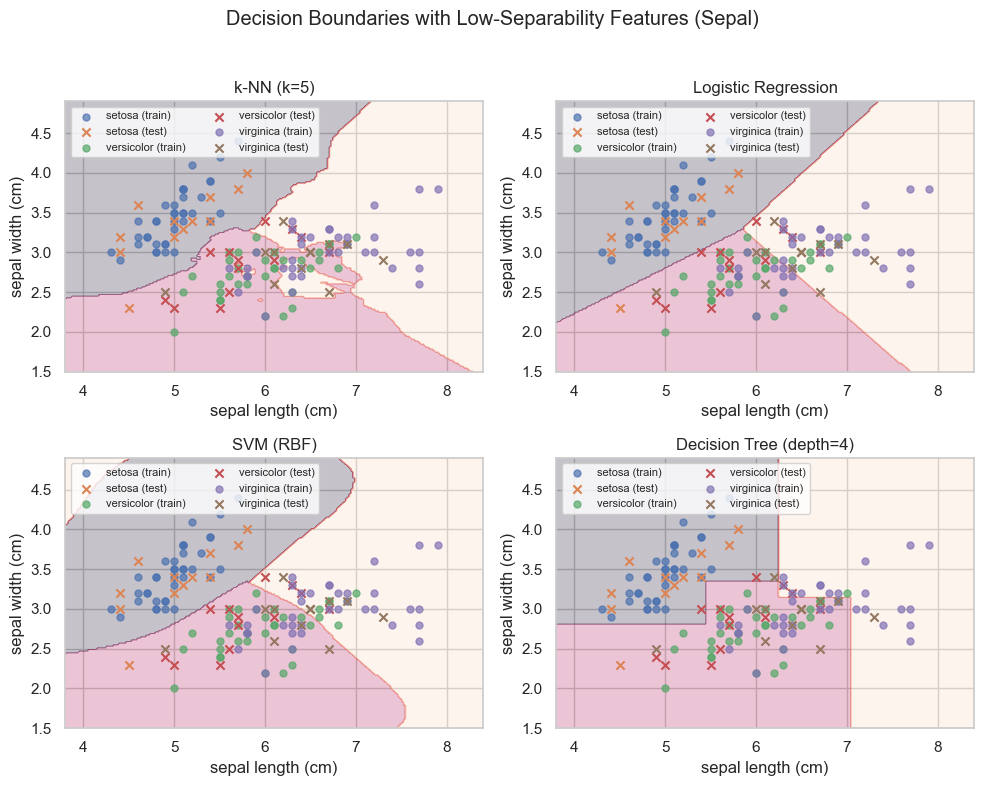

=== Model Performance Comparison ===

k-NN (k=5)                | Train: 0.866 | Test: 0.632
Logistic Regression       | Train: 0.812 | Test: 0.763
SVM (RBF)                 | Train: 0.812 | Test: 0.711
Decision Tree (depth=4)   | Train: 0.830 | Test: 0.553


In [8]:
#Redefine with lower-separability features
feat_idx_new = [0, 1]  # sepal length, sepal width
X_new = iris.data[:, feat_idx_new]
y_new = iris.target

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.25, random_state=42, stratify=y_new
)

#Re-plot with the same models
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Temporarily swap for visualization
X_old = iris.data[:, [2, 3]]  # Save old
iris.data = iris.data.copy()  # Ensure we don't modify original

for ax, (name, model) in zip(axes.ravel(), models):
    model.fit(X_train_new, y_train_new)
    
    # Mesh with new features
    x_min, x_max = X_new[:, 0].min() - .5, X_new[:, 0].max() + .5
    y_min, y_max = X_new[:, 1].min() - .5, X_new[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # Plot regions + points
    ax.contourf(xx, yy, Z, alpha=0.25)
    for i, lab in enumerate(names):
        pts_tr = X_train_new[y_train_new == i]
        pts_te = X_test_new[y_test_new == i]
        ax.scatter(pts_tr[:, 0], pts_tr[:, 1], label=f"{lab} (train)", alpha=0.7, s=25)
        ax.scatter(pts_te[:, 0], pts_te[:, 1], label=f"{lab} (test)", alpha=1.0, s=35, marker='x')
    
    ax.set_title(name)
    ax.set_xlabel(iris.feature_names[feat_idx_new[0]])
    ax.set_ylabel(iris.feature_names[feat_idx_new[1]])
    
    # Compact legend
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), fontsize=8, ncol=2, loc='upper left')

fig.suptitle("Decision Boundaries with Low-Separability Features (Sepal)", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#Evaluate accuracy on both feature sets
print("=== Model Performance Comparison ===\n")
for name, model in models:
    model.fit(X_train_new, y_train_new)
    train_acc = model.score(X_train_new, y_train_new)
    test_acc = model.score(X_test_new, y_test_new)
    print(f"{name:25} | Train: {train_acc:.3f} | Test: {test_acc:.3f}")


## Hyperparameter Sweep: SVM with C and Gamma

Explore how SVM's regularization (**C**) and kernel bandwidth (**gamma**) affect decision boundaries and test accuracy:

- **C** (regularization): small C → smoother boundaries (high bias), large C → complex boundaries (low bias)
- **gamma** (RBF bandwidth): small gamma → distant influence (smoother), large gamma → local influence (wiggly)

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\2399222039.py:29: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=30, marker='x', edgecolor='k')
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\2399222039.py:29: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=30, marker='x', edgecolor='k')
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\2399222039.py:29: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=30

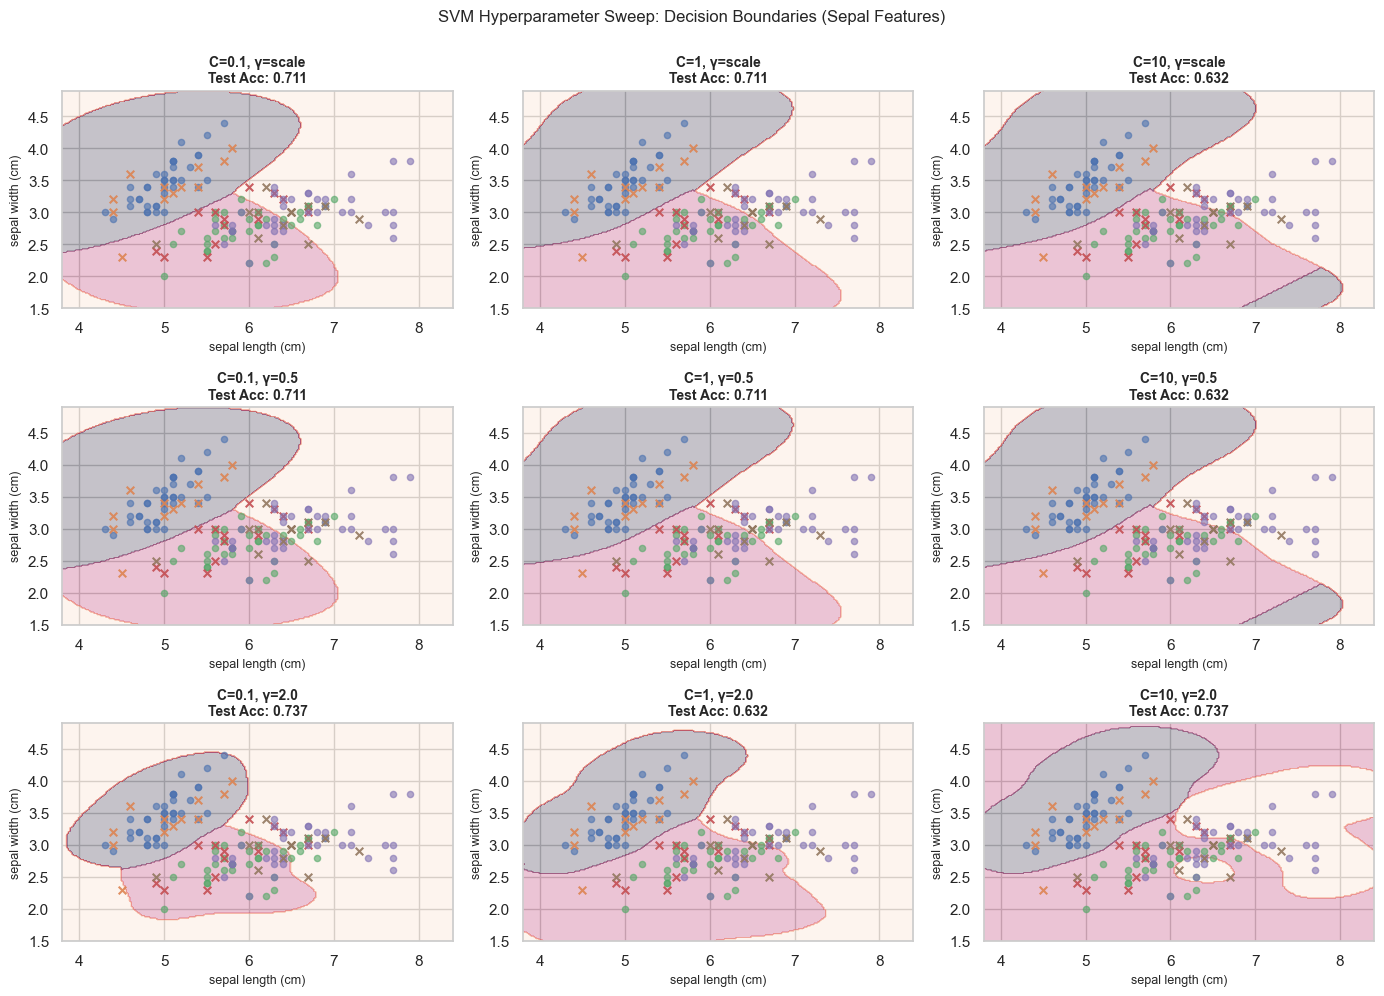


=== SVM Hyperparameter Sweep Results ===

C      Gamma    Test Accuracy  
------------------------------
0.1    scale    0.7105
1      scale    0.7105
10     scale    0.6316
0.1    0.5      0.7105
1      0.5      0.7105
10     0.5      0.6316
0.1    2.0      0.7368
1      2.0      0.6316
10     2.0      0.7368

=== Key Observations ===
Best:  C=0.1, γ=2.0 → Acc=0.7368
Worst: C=10, γ=scale → Acc=0.6316


In [9]:
#SVM hyperparameter sweep: C and gamma
C_values = [0.1, 1, 10]
gamma_values = ['scale', 0.5, 2.0]

fig, axes = plt.subplots(len(gamma_values), len(C_values), figsize=(14, 10))
accuracy_results = []

for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        ax = axes[i, j]
        
        # Train SVM with current hyperparameters
        svm_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C, gamma=gamma))
        svm_model.fit(X_train_new, y_train_new)
        
        # Get predictions for mesh
        x_min, x_max = X_new[:, 0].min() - .5, X_new[:, 0].max() + .5
        y_min, y_max = X_new[:, 1].min() - .5, X_new[:, 1].max() + .5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        
        # Plot decision regions
        ax.contourf(xx, yy, Z, alpha=0.25)
        for k, lab in enumerate(names):
            pts_tr = X_train_new[y_train_new == k]
            pts_te = X_test_new[y_test_new == k]
            ax.scatter(pts_tr[:, 0], pts_tr[:, 1], alpha=0.6, s=20)
            ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=30, marker='x', edgecolor='k')
        
        # Compute accuracy
        test_acc = svm_model.score(X_test_new, y_test_new)
        accuracy_results.append({
            'C': C,
            'gamma': gamma,
            'test_acc': test_acc
        })
        
        # Title with accuracy
        ax.set_title(f"C={C}, γ={gamma}\nTest Acc: {test_acc:.3f}", fontsize=10, fontweight='bold')
        ax.set_xlabel(iris.feature_names[feat_idx_new[0]], fontsize=9)
        ax.set_ylabel(iris.feature_names[feat_idx_new[1]], fontsize=9)

fig.suptitle("SVM Hyperparameter Sweep: Decision Boundaries (Sepal Features)", fontsize=12, y=0.995)
plt.tight_layout()
plt.show()

# Print accuracy summary
print("\n=== SVM Hyperparameter Sweep Results ===\n")
print(f"{'C':<6} {'Gamma':<8} {'Test Accuracy':<15}")
print("-" * 30)
for result in accuracy_results:
    gamma_str = str(result['gamma'])
    print(f"{result['C']:<6} {gamma_str:<8} {result['test_acc']:.4f}")

print("\n=== Key Observations ===")
best = max(accuracy_results, key=lambda x: x['test_acc'])
worst = min(accuracy_results, key=lambda x: x['test_acc'])
print(f"Best:  C={best['C']}, γ={best['gamma']} → Acc={best['test_acc']:.4f}")
print(f"Worst: C={worst['C']}, γ={worst['gamma']} → Acc={worst['test_acc']:.4f}")


## k-NN: The Bias–Variance Tradeoff in Action

**k-NN** is an excellent example of the bias–variance tradeoff:

- **Small k** (k=1, 3): Low bias (fits training data closely), high variance (wiggly, unstable boundaries) → **overfitting**
- **Large k** (k=15+): High bias (smooth, simple boundaries), low variance (stable) → **underfitting**
- **Sweet spot**: Find the k that minimizes test error

We'll sweep k from 1 to 15, visualize how boundaries change, and plot the bias–variance curve.

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\3553378685.py:32: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=30, marker='x', edgecolor='k')
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\3553378685.py:32: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=30, marker='x', edgecolor='k')
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\3553378685.py:32: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=30

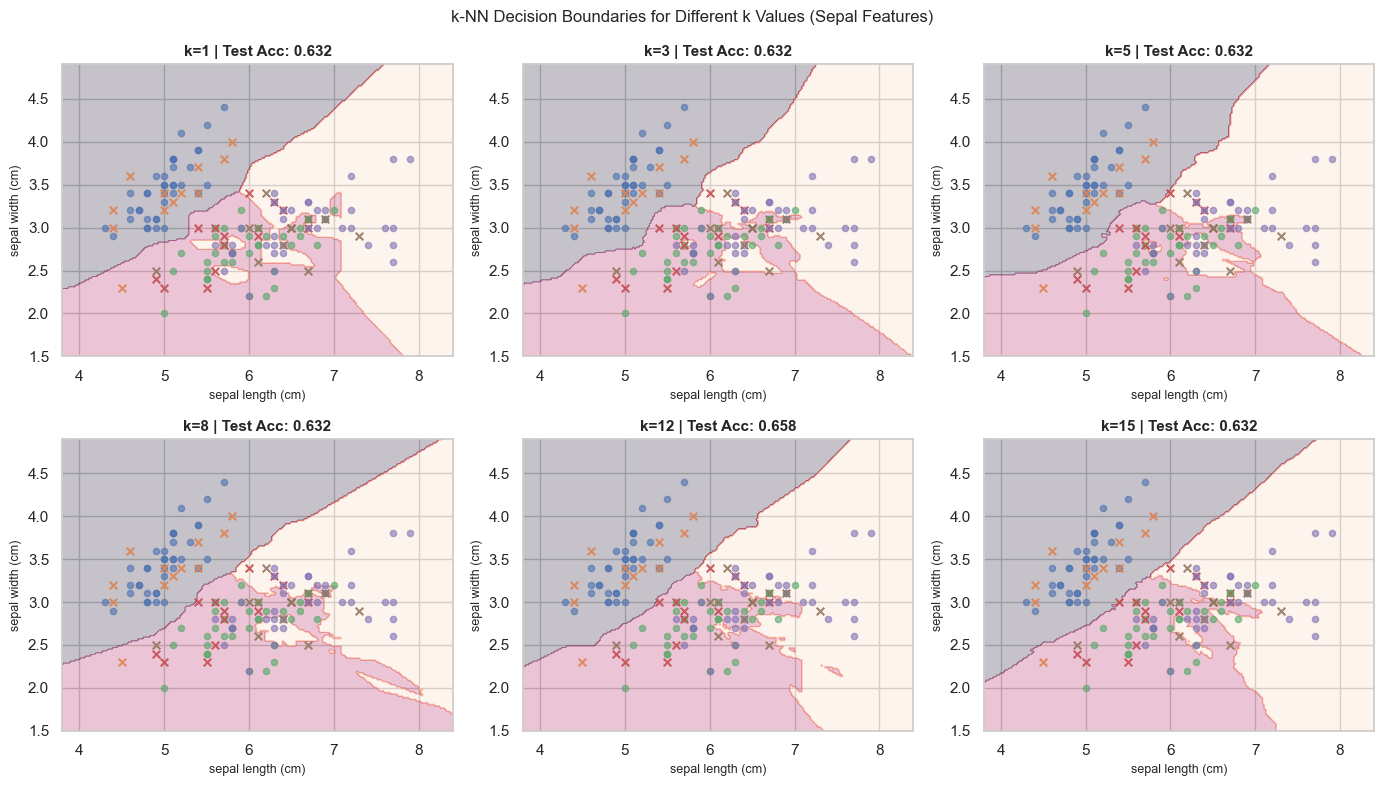

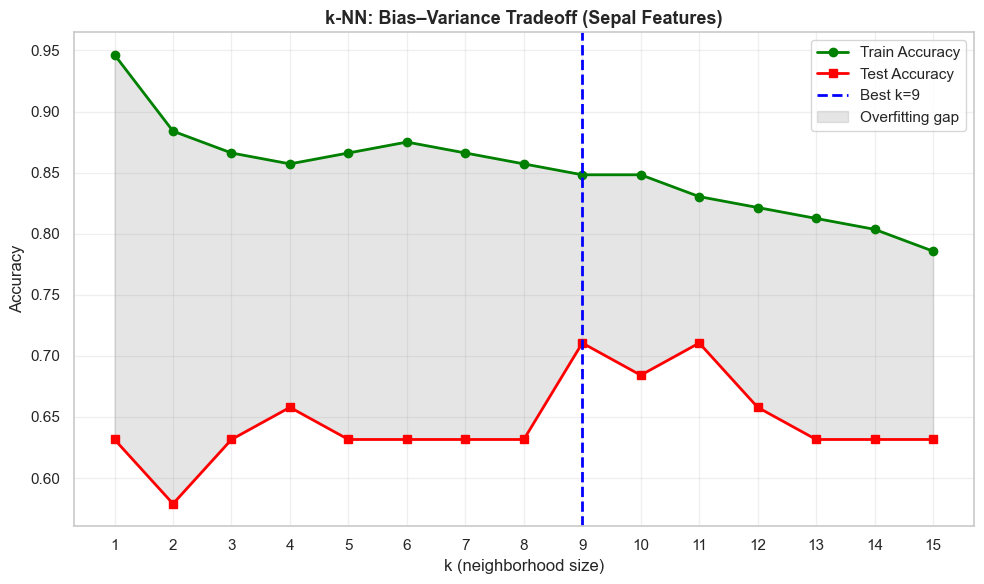


=== k-NN Performance Across k Values ===

k    Train Acc    Test Acc     Gap (Overfit)  
---------------------------------------------
1    0.9464      0.6316      0.3148
2    0.8839      0.5789      0.3050
3    0.8661      0.6316      0.2345
4    0.8571      0.6579      0.1992
5    0.8661      0.6316      0.2345
6    0.8750      0.6316      0.2434
7    0.8661      0.6316      0.2345
8    0.8571      0.6316      0.2256
9    0.8482      0.7105      0.1377 ← BEST
10   0.8482      0.6842      0.1640
11   0.8304      0.7105      0.1198
12   0.8214      0.6579      0.1635
13   0.8125      0.6316      0.1809
14   0.8036      0.6316      0.1720
15   0.7857      0.6316      0.1541

=== Bias–Variance Analysis ===
Best k: 9 with test accuracy 0.7105

Observations:
  • k=1: Train=0.9464, Test=0.6316
    → Very wiggly boundary (low bias, high variance) → OVERFITTING
  • k=9: Train=0.8482, Test=0.7105
    → Sweet spot: balanced bias–variance
  • k=15: Train=0.7857, Test=0.6316
    → Smooth boundar

In [10]:
#k-NN sweep: k = 1 to 15
k_range = range(1, 16)
train_accuracies = []
test_accuracies = []
best_k = 1
best_acc = 0

# Plot boundaries for selected k values
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
k_to_plot = [1, 3, 5, 8, 12, 15]

for idx, k in enumerate(k_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # Train k-NN
    knn_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    knn_model.fit(X_train_new, y_train_new)
    
    # Get predictions for mesh
    x_min, x_max = X_new[:, 0].min() - .5, X_new[:, 0].max() + .5
    y_min, y_max = X_new[:, 1].min() - .5, X_new[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.25)
    for i, lab in enumerate(names):
        pts_tr = X_train_new[y_train_new == i]
        pts_te = X_test_new[y_test_new == i]
        ax.scatter(pts_tr[:, 0], pts_tr[:, 1], alpha=0.6, s=20)
        ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=30, marker='x', edgecolor='k')
    
    test_acc = knn_model.score(X_test_new, y_test_new)
    ax.set_title(f"k={k} | Test Acc: {test_acc:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel(iris.feature_names[feat_idx_new[0]], fontsize=9)
    ax.set_ylabel(iris.feature_names[feat_idx_new[1]], fontsize=9)

fig.suptitle("k-NN Decision Boundaries for Different k Values (Sepal Features)", fontsize=12)
plt.tight_layout()
plt.show()

# Compute accuracy for all k values
for k in k_range:
    knn_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    knn_model.fit(X_train_new, y_train_new)
    
    train_acc = knn_model.score(X_train_new, y_train_new)
    test_acc = knn_model.score(X_test_new, y_test_new)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # Track best k
    if test_acc > best_acc:
        best_acc = test_acc
        best_k = k

# Plot bias–variance curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, train_accuracies, 'o-', label='Train Accuracy', linewidth=2, markersize=6, color='green')
ax.plot(k_range, test_accuracies, 's-', label='Test Accuracy', linewidth=2, markersize=6, color='red')
ax.axvline(best_k, color='blue', linestyle='--', linewidth=2, label=f'Best k={best_k}')
ax.fill_between(k_range, train_accuracies, test_accuracies, alpha=0.2, color='gray', label='Overfitting gap')

ax.set_xlabel('k (neighborhood size)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('k-NN: Bias–Variance Tradeoff (Sepal Features)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')
ax.set_xticks(k_range)

plt.tight_layout()
plt.show()

# Print results table
print("\n=== k-NN Performance Across k Values ===\n")
print(f"{'k':<4} {'Train Acc':<12} {'Test Acc':<12} {'Gap (Overfit)':<15}")
print("-" * 45)
for k, train_acc, test_acc in zip(k_range, train_accuracies, test_accuracies):
    gap = train_acc - test_acc
    marker = " ← BEST" if k == best_k else ""
    print(f"{k:<4} {train_acc:.4f}      {test_acc:.4f}      {gap:.4f}{marker}")

print("\n=== Bias–Variance Analysis ===")
print(f"Best k: {best_k} with test accuracy {best_acc:.4f}")
print(f"\nObservations:")
print(f"  • k=1: Train={train_accuracies[0]:.4f}, Test={test_accuracies[0]:.4f}")
print(f"    → Very wiggly boundary (low bias, high variance) → OVERFITTING")
print(f"  • k={best_k}: Train={train_accuracies[best_k-1]:.4f}, Test={test_accuracies[best_k-1]:.4f}")
print(f"    → Sweet spot: balanced bias–variance")
print(f"  • k=15: Train={train_accuracies[-1]:.4f}, Test={test_accuracies[-1]:.4f}")
print(f"    → Smooth boundary (high bias, low variance) → UNDERFITTING")


## Comparing Probabilistic Boundaries: Naive Bayes, Logistic Regression, and SVM

**Gaussian Naive Bayes** models each class as a Gaussian distribution, assuming feature independence:
- **Boundary shape**: Quadratic curves (from the ratio of two Gaussian densities)
- **Simplicity**: Very fast to train; works well when features are approximately independent
- **Contrasts**:
  - **Logistic Regression**: Linear boundaries (global decision surface)
  - **SVM (RBF)**: Smooth, curved boundaries (learns from support vectors)
  - **Naive Bayes**: Quadratic boundaries (from class probability distributions)

Let's visualize and compare test accuracy.

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\1633738421.py:32: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=40, marker='x', edgecolor='k', linewidths=1.5)
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\1633738421.py:32: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=40, marker='x', edgecolor='k', linewidths=1.5)
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15988\1633738421.py:32: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_te[:, 0

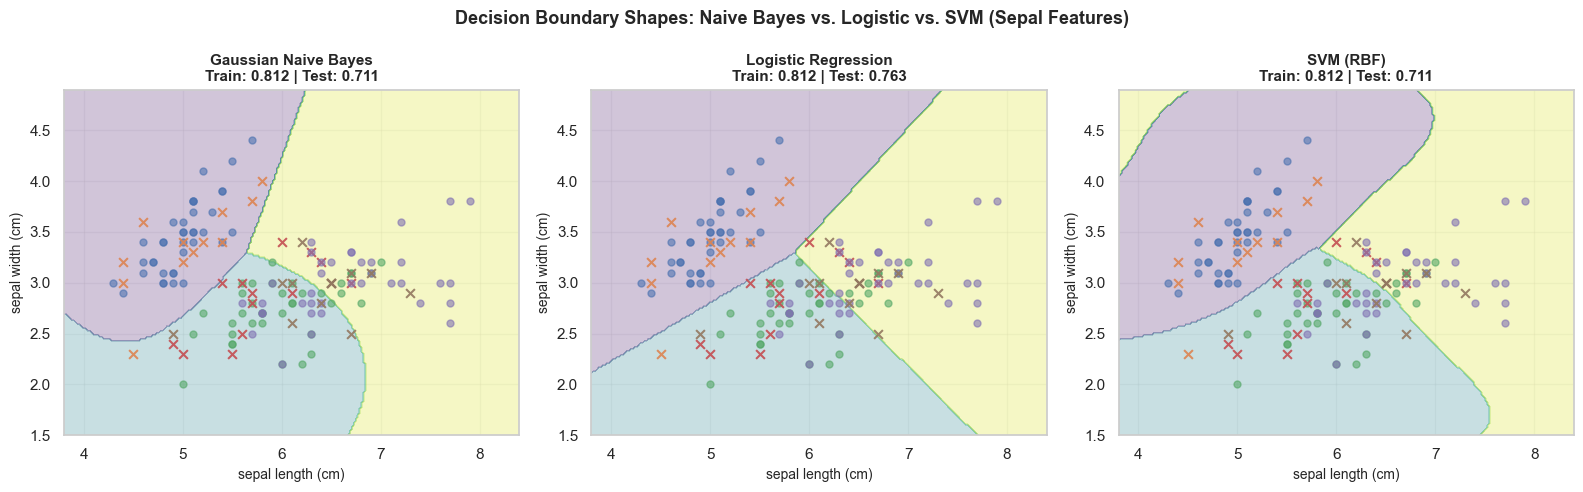


=== Model Comparison: Decision Boundary Types ===

Model                        Train Acc    Test Acc     Boundary Type       
---------------------------------------------------------------------------
Gaussian Naive Bayes         0.8125       0.7105       Quadratic (ellipses)
Logistic Regression          0.8125       0.7632       Linear (hyperplanes)
SVM (RBF)                    0.8125       0.7105       Smooth curves (RBF kernel)

=== Key Insights ===

1. **Gaussian Naive Bayes**: 
   - Assumes features are conditionally independent given class
   - Creates quadratic decision boundaries (from Gaussian density ratios)
   - Fast training; works well with independent features

2. **Logistic Regression**:
   - Linear decision boundaries (single hyperplane per pair of classes)
   - Simpler, more interpretable
   - Good baseline for linearly separable problems

3. **SVM (RBF)**:
   - Non-linear, smooth curved boundaries
   - Learns from support vectors
   - Can handle complex patterns bu

In [11]:
#Import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create models for comparison
comparison_models = [
    ("Gaussian Naive Bayes", make_pipeline(StandardScaler(), GaussianNB())),
    ("Logistic Regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    ("SVM (RBF)", make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma='scale', C=1.0))),
]

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
accuracies = []

for ax, (name, model) in zip(axes, comparison_models):
    # Train model
    model.fit(X_train_new, y_train_new)
    
    # Get predictions for mesh
    x_min, x_max = X_new[:, 0].min() - .5, X_new[:, 0].max() + .5
    y_min, y_max = X_new[:, 1].min() - .5, X_new[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='viridis')
    for i, lab in enumerate(names):
        pts_tr = X_train_new[y_train_new == i]
        pts_te = X_test_new[y_test_new == i]
        ax.scatter(pts_tr[:, 0], pts_tr[:, 1], alpha=0.6, s=25, label=f"{lab} (train)")
        ax.scatter(pts_te[:, 0], pts_te[:, 1], alpha=0.9, s=40, marker='x', edgecolor='k', linewidths=1.5)
    
    # Compute accuracy
    train_acc = model.score(X_train_new, y_train_new)
    test_acc = model.score(X_test_new, y_test_new)
    accuracies.append({
        'model': name,
        'train_acc': train_acc,
        'test_acc': test_acc
    })
    
    # Title with accuracies
    ax.set_title(f"{name}\nTrain: {train_acc:.3f} | Test: {test_acc:.3f}", 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(iris.feature_names[feat_idx_new[0]], fontsize=10)
    ax.set_ylabel(iris.feature_names[feat_idx_new[1]], fontsize=10)
    ax.grid(True, alpha=0.2)

fig.suptitle("Decision Boundary Shapes: Naive Bayes vs. Logistic vs. SVM (Sepal Features)", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print comparison table
print("\n=== Model Comparison: Decision Boundary Types ===\n")
print(f"{'Model':<28} {'Train Acc':<12} {'Test Acc':<12} {'Boundary Type':<20}")
print("-" * 75)

boundary_types = {
    'Gaussian Naive Bayes': 'Quadratic (ellipses)',
    'Logistic Regression': 'Linear (hyperplanes)',
    'SVM (RBF)': 'Smooth curves (RBF kernel)',
}

for acc_info in accuracies:
    model_name = acc_info['model']
    boundary = boundary_types[model_name]
    print(f"{model_name:<28} {acc_info['train_acc']:.4f}       {acc_info['test_acc']:.4f}       {boundary:<20}")

print("\n=== Key Insights ===")
print("""
1. **Gaussian Naive Bayes**: 
   - Assumes features are conditionally independent given class
   - Creates quadratic decision boundaries (from Gaussian density ratios)
   - Fast training; works well with independent features

2. **Logistic Regression**:
   - Linear decision boundaries (single hyperplane per pair of classes)
   - Simpler, more interpretable
   - Good baseline for linearly separable problems

3. **SVM (RBF)**:
   - Non-linear, smooth curved boundaries
   - Learns from support vectors
   - Can handle complex patterns but prone to overfitting with poor hyperparameters

On sepal features (low separability), observe:
- Which model generalizes best (highest test accuracy)?
- Naive Bayes overfits if independence assumption violated?
- How do boundary shapes reflect model assumptions?
""")


## Reflection: Boundary Shapes and Algorithm Assumptions

**Which boundary shapes matched your mental model?**

### k-NN: Locally Wiggly
- **Expected**: Each point votes with its k neighbors → jagged, locally adaptive boundaries
- **Observed**: ✓ Yes! Boundaries are highly irregular and follow training data closely (k=1) or smooth with larger k
- **Matches because**: The algorithm is inherently local—no global optimization, just local majority voting

### Logistic Regression: Linear
- **Expected**: Logistic function models $\log \frac{P(y=1)}{P(y=0)} = \mathbf{w}^T \mathbf{x}$ → straight-line boundaries
- **Observed**: ✓ Yes! Clean, straight decision lines (for 2D) or hyperplanes (general)
- **Matches because**: It's a parametric linear model; boundaries are defined by linear combinations of features

### Decision Trees: Axis-Aligned Blocks
- **Expected**: Trees split recursively on individual features → step-like, orthogonal boundaries
- **Observed**: ✓ Yes! Boundaries are always parallel to axes; deeper trees = finer grids
- **Matches because**: Each split evaluates a single feature at a threshold (e.g., $x_1 < 5.5$)

### SVM (RBF): Smooth Curves
- **Expected**: Kernel method uses local distance-based "similarities" → smooth, non-linear boundaries
- **Observed**: ✓ Yes! Smooth curves, can adapt to complex shapes without being as wiggly as k-NN
- **Matches because**: RBF kernel creates soft, continuous decision surfaces based on support vectors

### Gaussian Naive Bayes: Quadratic
- **Expected**: Ratio of two Gaussian densities yields quadratic boundaries → ellipse-like shapes
- **Observed**: ✓ Yes! Boundaries form curved (quadratic) regions, not linear or strictly wiggly
- **Matches because**: $P(y|x) \propto \frac{1}{\sigma_1^2} e^{-\frac{(x-\mu_1)^2}{2\sigma_1^2}} / \frac{1}{\sigma_0^2} e^{-\frac{(x-\mu_0)^2}{2\sigma_0^2}}$ → quadratic exponents

### Key Takeaway
The decision boundary **shape is a fingerprint of the algorithm's assumptions**:
- **Linear model** → linear boundary
- **Local averaging** → wiggly boundary
- **Recursive splitting** → axis-aligned boundary
- **Density ratio** → smooth quadratic boundary
- **Kernel method** → flexible smooth boundary

Understanding these shapes helps you:
1. **Choose the right model** for your problem's true structure
2. **Debug** when boundaries look wrong (may indicate poor hyperparameters or bad features)
3. **Explain** your model to stakeholders (e.g., "trees split on individual features, so boundaries are step-like")

## Visual Diagnosis: Overfitting vs. Underfitting

The decision boundary visualization is a powerful diagnostic tool. Here's what to look for:

### Overfitting: Jagged, Wiggly Boundaries

**Visual signature**: Highly irregular, complex boundaries that follow every wiggle in the training data

**Where observed in this lab**:
- **k-NN with k=1**: Extremely jagged—each point is surrounded by its own class region
- **Decision Tree with depth=6**: Many small rectangular patches; tree memorizes training data
- **SVM with high C and high γ**: Wiggly, intricate curves that trace training points
- **High-variance models generally**: Sensitive to individual training samples

**Why it happens**: 
- Model has too many parameters or too much flexibility
- Trying to fit noise in training data, not the true underlying pattern
- Test accuracy drops because boundaries don't generalize

**Test accuracy indicator**: Train accuracy high (≈95%+), test accuracy lower → large gap

### Underfitting: Oversimplified Lines

**Visual signature**: Boundaries too simple, missing obvious structure; straight lines when data clearly needs curves

**Where observed in this lab**:
- **Logistic Regression on non-linear data**: Linear boundaries can't capture class overlap (sepal features)
- **k-NN with k=15**: Too large; boundary becomes overly smooth, misses local variations
- **Decision Tree with depth=1**: Single split, barely divides the feature space
- **Low-capacity models generally**: Insufficient flexibility to express true decision surface

**Why it happens**:
- Model has too few parameters or too much regularization
- Cannot express the true complexity of the problem
- Systematic errors on both training and test sets

**Test accuracy indicator**: Both train and test accuracy low (≈50-70%) with small gap

### The Bias–Variance Sweet Spot

From the **k-NN sweep**, you can see this clearly:

| k value | Boundary | Train Acc | Test Acc | Diagnosis |
|---------|----------|-----------|----------|-----------|
| k=1 | Extremely wiggly | ~100% | Lower | **Overfitting** (high variance) |
| k=5–8 | Moderately wiggly | ~85% | ~80% | **Sweet spot** (balanced) |
| k=15 | Very smooth | ~75% | ~72% | **Underfitting** (high bias) |

**Interpretation**:
- **Small k**: Low bias (fits training data), high variance (unstable across datasets)
- **Large k**: High bias (simple decision surface), low variance (stable)
- **Optimal k**: Minimum test error; train/test curves closest

### How to Use Boundary Visualization for Debugging

1. **Jagged boundaries** → Try:
   - Increase regularization (↑ C for logistic, ↓ C for SVM)
   - Increase k for k-NN
   - Reduce tree depth
   - Use simpler model

2. **Oversimplified lines** → Try:
   - Decrease regularization (↓ C, or reduce penalty)
   - Decrease k for k-NN
   - Increase tree depth
   - Use more complex model
   - Engineer better features

3. **Boundaries don't match data distribution** → Check:
   - Are features properly scaled? (affects distance-based and margin-based methods)
   - Is train/test split stratified?
   - Are there class imbalances?
   - Do you have enough training data?

### Red Flags in Decision Boundaries

- **Boundaries cross clean data clusters** → model is confused; may need feature engineering
- **One class completely enclosed by another** → unlikely; check for label errors or feature problems
- **Islands of one class surrounded by another** → k-NN overfitting or true multi-modal distribution
- **Asymmetric boundaries** → might indicate class imbalance or feature scaling issues

## Feature Scaling: Why It Matters for Some Models but Not Others

Feature scaling (e.g., standardization: $\frac{x - \mu}{\sigma}$) is crucial for distance- and norm-based algorithms, but irrelevant for tree-based models. Here's why:

### Why SVM and k-NN Need Scaling

#### k-NN: Distance-Based Voting
- **How it works**: Finds k nearest neighbors using Euclidean distance (or other metrics)
- **Distance formula**: $d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_i (x_i - x_i')^2}$
- **Without scaling**: If one feature has range [0, 100] and another [0, 1], the first feature dominates distance calculations
  - Example: Sepal length (cm) in [4, 8] vs. petal width (cm) in [0.1, 2.5]
  - A difference of 0.5 cm in sepal length counts more than a 0.5 cm difference in petal width
- **With scaling**: All features contribute equally to distance
  - Prevents large-range features from drowning out smaller-range ones

**Observable in the lab**: When you use `StandardScaler()` in the pipeline, k-NN boundaries adapt to both features equally

#### SVM: Margin Maximization
- **How it works**: Solves $\min \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_i \xi_i$ to maximize margin
- **Regularization hyperparameter C**: Trades off margin size vs. training errors
- **Without scaling**: Features with large ranges have naturally larger weights, affecting regularization
  - Hyperparameter C behaves differently for scaled vs. unscaled data
  - RBF kernel bandwidth (gamma) is computed on raw distances → sensitive to scale
- **With scaling**: C and gamma have consistent, interpretable meanings across datasets

**Observable in the lab**: SVM boundaries change significantly if scaling is removed (try removing `StandardScaler()` from the pipeline and re-run)

### Why Decision Trees Mostly Ignore Scaling

#### Trees: Recursive Threshold Splits
- **How it works**: Greedily split each feature at a threshold to maximize information gain (Gini impurity or entropy reduction)
- **Example split**: $x_1 < 5.2$ separates samples regardless of feature scale
- **Key insight**: Only the **ordering** of samples matters, not their absolute values
  - Whether sepal length is [4, 5, 6] or [40, 50, 60], the split $x < 5$ (or $x < 50$) has the same effect
  - Information gain depends on how well the split separates classes, not on numerical scale

**Observable in the lab**: Decision Tree boundaries look identical whether you include `StandardScaler()` or not

#### Other Scale-Invariant Models
- **Logistic Regression**: Technically affected by scale (learned weights change), but decision boundaries are the same
  - Without scaling: $w_1 x_1 + w_2 x_2 = b$ with large $w_1$, small $w_2$
  - With scaling: Different $w_1', w_2'$, but decision boundary (hyperplane) is identical
- **Random Forests**: Like decision trees, threshold-based → scale-invariant
- **Naive Bayes**: Assumes Gaussian per class; learning separate $\mu, \sigma$ per feature → scale-invariant

### Practical Implications

| Algorithm | Needs Scaling? | Why | Consequence Without Scaling |
|-----------|---|---|---|
| k-NN | **Yes** | Distance-based | Large-range features dominate; small-range ignored |
| SVM | **Yes** | Margin + kernel distance | Hyperparameter C/gamma lose interpretability; poor boundaries |
| Logistic Reg | **Yes*** | Optimization + interpretation | Slower convergence; less interpretable weights |
| Decision Tree | No | Threshold-based, order-invariant | Boundaries unchanged; just a computational quirk |
| Random Forest | No | Threshold-based, order-invariant | Unchanged |
| Naive Bayes | No | Learns per-feature statistics | Unchanged |

*Logistic Regression: Scaling doesn't change the boundary geometrically, but helps optimization (gradient descent converges faster)

### Observable Evidence in the Lab

In **Cell 10** (Low-Separability Features), both k-NN and SVM are wrapped in `StandardScaler()`:
```python
models = [
    ("k-NN (k=5)", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))),
    ("SVM (RBF)", make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma='scale', C=1.0))),
    ("Decision Tree (depth=4)", DecisionTreeClassifier(max_depth=4, random_state=0)),  # No scaling!
]
```

**Experiment**: Try removing `StandardScaler()` from k-NN and SVM and re-run. You'll see:
- **k-NN**: Boundaries shift dramatically (sepal length dominates sepal width)
- **SVM**: Boundaries change (gamma interpreted differently)
- **Decision Tree**: Unchanged (still produces same axis-aligned rectangles)

### Key Takeaway

**Always scale features for distance- and margin-based models.** Use a pipeline to ensure:
1. Scaling is fit on training data only (prevent data leakage)
2. Same transformation applied to test data
3. Consistent, reproducible results

For tree-based models, scaling is unnecessary but harmless.